In [4]:
import pandas as pd
import numpy as np

In [5]:
dataset = pd.read_csv("twitter.csv")

In [6]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [7]:
dataset.isnull().sum()

,0
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [9]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [10]:
dataset["labels"] = dataset["class"].map({0: "Hate speech",
                                         1:"Offensive speech",
                                         2:"No hate or Offensive languages"})

In [11]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or Offensive languages
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive speech
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive speech
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive speech
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive speech
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive speech
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",No hate or Offensive languages
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive speech
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive speech


In [12]:
data = dataset[["tweet", "labels"]]

In [13]:
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or Offensive languages
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive speech
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive speech
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive speech
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive speech
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive speech
24779,"you've gone and broke the wrong heart baby, an...",No hate or Offensive languages
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive speech
24781,youu got wild bitches tellin you lies,Offensive speech


In [14]:
import re
import nltk
import string


In [15]:
# importing of stop words
from nltk.corpus import stopwords
nltk.download("stopwords")
stopwords = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
# importing stemmer
stemmer = nltk.SnowballStemmer("english")

In [17]:

def clean_data(text):
    text = str(text).lower()


    text = re.sub(r'https?://\S+|www\.\S+', '', text)


    text = re.sub(r'@\w+', '', text)


    text = re.sub(r'\[.*?\]', '', text)


    text = re.sub(r'[^\w\s]', '', text)


    text = re.sub(r'\w*\d\w*', '', text)


    text = [word for word in text.split(' ') if word not in stopwords]
    text = " ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text = " ".join(text)

    return text.strip()

In [18]:
data["tweet"] = data["tweet"].apply(clean_data)

/tmp/ipykernel_1737/1832165696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


In [19]:
data

,tweet,labels
0,rt woman shouldnt complain clean hous amp man...,No hate or Offensive languages
1,rt boy dat coldtyga dwn bad cuffin dat hoe p...,Offensive speech
2,rt dawg rt ever fuck bitch start cri confus ...,Offensive speech
3,rt look like tranni,Offensive speech
4,rt shit hear might true might faker bitch tol...,Offensive speech
...,...,...
24778,yous muthafin lie right tl trash mine bibl...,Offensive speech
24779,youv gone broke wrong heart babi drove redneck...,No hate or Offensive languages
24780,young buck wanna eat dat nigguh like aint fuck...,Offensive speech
24781,youu got wild bitch tellin lie,Offensive speech


In [20]:
x = np.array(data["tweet"])
y = np.array(data["labels"])

In [21]:
x

array(['rt  woman shouldnt complain clean hous amp man alway take trash',
       'rt  boy dat coldtyga dwn bad cuffin dat hoe  place',
       'rt  dawg rt  ever fuck bitch start cri confus shit', ...,
       'young buck wanna eat dat nigguh like aint fuckin dis',
       'youu got wild bitch tellin lie',
       'ruffl  ntac eileen dahlia  beauti color combin pink orang yellow amp white coll'],
      dtype=object)

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [23]:
cv = CountVectorizer()
x = cv.fit_transform(x)

In [24]:
x

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 184903 stored elements and shape (24783, 16737)>

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [26]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 123976 stored elements and shape (16604, 16737)>

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [29]:
y_pred = dt.predict (x_test)

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 181,   36,  248],
       [  43, 1075,  261],
       [ 286,  210, 5839]])

In [31]:
import seaborn as sns
import matplotlib.pyplot as ply
%matplotlib inline

<Axes: >

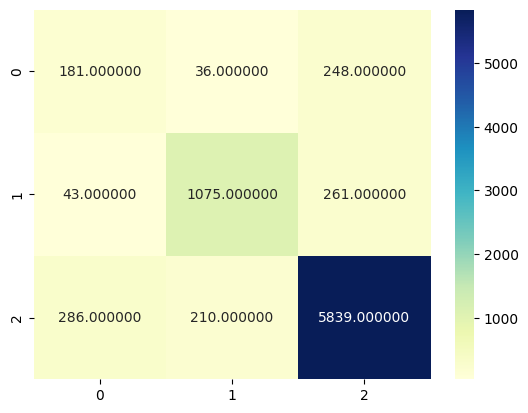

In [32]:
sns.heatmap (cm, annot = True, fmt="f", cmap = "YlGnBu")

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score (y_test, y_pred)

0.8674654603252231

In [34]:
sample = "Let's unite and kill all the people who are protesting against the government"
sample = clean_data(sample)

In [35]:
sample

'let unit kill peopl protest govern'

In [36]:
data1 = cv.transform ([sample]).toarray()

In [37]:
data1

array([[0, 0, 0, ..., 0, 0, 0]])

In [38]:
dt.predict(data1)

array(['Hate speech'], dtype=object)

In [39]:
def predict_tweet(sample_text):

    cleaned_sample = clean_data(sample_text)


    vectorized_sample = cv.transform([cleaned_sample]).toarray()


    prediction = dt.predict(vectorized_sample)[0]


    print(f"\n📢 Input Text: '{sample_text}'")
    print(f"🤖 Prediction:  🌟 {prediction} 🌟\n")
    print("-" * 50)


predict_tweet("Let's unite and kill all the people who are protesting against the government")


📢 Input Text: 'Let's unite and kill all the people who are protesting against the government'
🤖 Prediction:  🌟 Hate speech 🌟

--------------------------------------------------


In [40]:
predict_tweet ("Let's kill all the protester")


📢 Input Text: 'Let's kill all the protester'
🤖 Prediction:  🌟 Hate speech 🌟

--------------------------------------------------


In [41]:
predict_tweet ("your mothefuckin ass wont's sit down")


📢 Input Text: 'your mothefuckin ass wont's sit down'
🤖 Prediction:  🌟 Offensive speech 🌟

--------------------------------------------------
